In [5]:
# 1. Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import tensorflow as tf

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten

In [6]:
# 2. Load data
csv_file = glob.glob('/content/*.csv')
data = pd.read_csv(csv_file[0])

print(data.head())
print(data.info())

         Date       Low      Open     Volume      High     Close  \
0  12-12-1980  0.128348  0.128348  469033600  0.128906  0.128348   
1  15-12-1980  0.121652  0.122210  175884800  0.122210  0.121652   
2  16-12-1980  0.112723  0.113281  105728000  0.113281  0.112723   
3  17-12-1980  0.115513  0.115513   86441600  0.116071  0.115513   
4  18-12-1980  0.118862  0.118862   73449600  0.119420  0.118862   

   Adjusted Close  
0        0.099874  
1        0.094663  
2        0.087715  
3        0.089886  
4        0.092492  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  object 
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6 

In [7]:
# 3. Select multiple features
features = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
target = 'Open'

df = data[features]

In [8]:
# 4. Create time windows
k = 3   # predict 3 consecutive days

X_data = []
y_data = []
window_size = 30
num_features = len(features)

for i in range(0, len(df) - window_size - k):
    data_feature = []

    for j in range(window_size):
        data_feature.append(df.iloc[i + j].values)

    label = df.iloc[i + window_size : i + window_size + k][target].values

    X_data.append(data_feature)
    y_data.append(label)

X_data = np.array(X_data)
y_data = np.array(y_data)

print("X shape:", X_data.shape)   # (samples, 30, 6)
print("y shape:", y_data.shape)   # (samples, k)

X shape: (10557, 30, 6)
y shape: (10557, 3)


In [9]:
# 5. Train / Val / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, shuffle=False)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=False)

In [10]:
# 6. Normalize
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape for scaler
X_train_reshaped = X_train.reshape(-1, num_features)
X_val_reshaped = X_val.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

# fit on train only
X_train_norm = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_val_norm = scaler_X.transform(X_val_reshaped).reshape(X_val.shape)
X_test_norm = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

# scale y
y_train_norm = scaler_y.fit_transform(y_train)
y_val_norm = scaler_y.transform(y_val)
y_test_norm = scaler_y.transform(y_test)

In [11]:
# 7. Build model
model = Sequential()

model.add(Conv1D(64, 3, activation='relu',
                   input_shape=(window_size, num_features), padding='same'))
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))

model.add(Flatten())
model.add(Dense(100, activation='relu'))

model.add(Dense(k))

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mse']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 8. Train model
history = model.fit(
    X_train_norm, y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=10,
    batch_size=128
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0020 - mse: 0.0020 - val_loss: 0.0283 - val_mse: 0.0283
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 2.2516e-04 - mse: 2.2516e-04 - val_loss: 0.0396 - val_mse: 0.0396
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.5952e-04 - mse: 1.5952e-04 - val_loss: 0.0423 - val_mse: 0.0423
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.2047e-04 - mse: 1.2047e-04 - val_loss: 0.0401 - val_mse: 0.0401
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.9919e-05 - mse: 9.9919e-05 - val_loss: 0.0644 - val_mse: 0.0644
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.0665e-04 - mse: 1.0665e-04 - val_loss: 0.0110 - val_mse: 0.0110
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.9008e-05 - mse: 6.9008e-05 - val_loss: 0.0271 - val_mse: 0.0271
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 7.6598e-05 - mse: 7.6598e-05 - val_loss: 0.0376 - val_mse: 0.0376
Epoch 9/

In [13]:
# 9. Evaluate
y_pred_norm = model.predict(X_test_norm)

print("MSE:", mean_squared_error(y_test_norm, y_pred_norm))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE: 4.072335836771793


In [14]:
# 10. Denormalize predictions
y_pred = scaler_y.inverse_transform(y_pred_norm)
y_test_real = scaler_y.inverse_transform(y_test_norm)

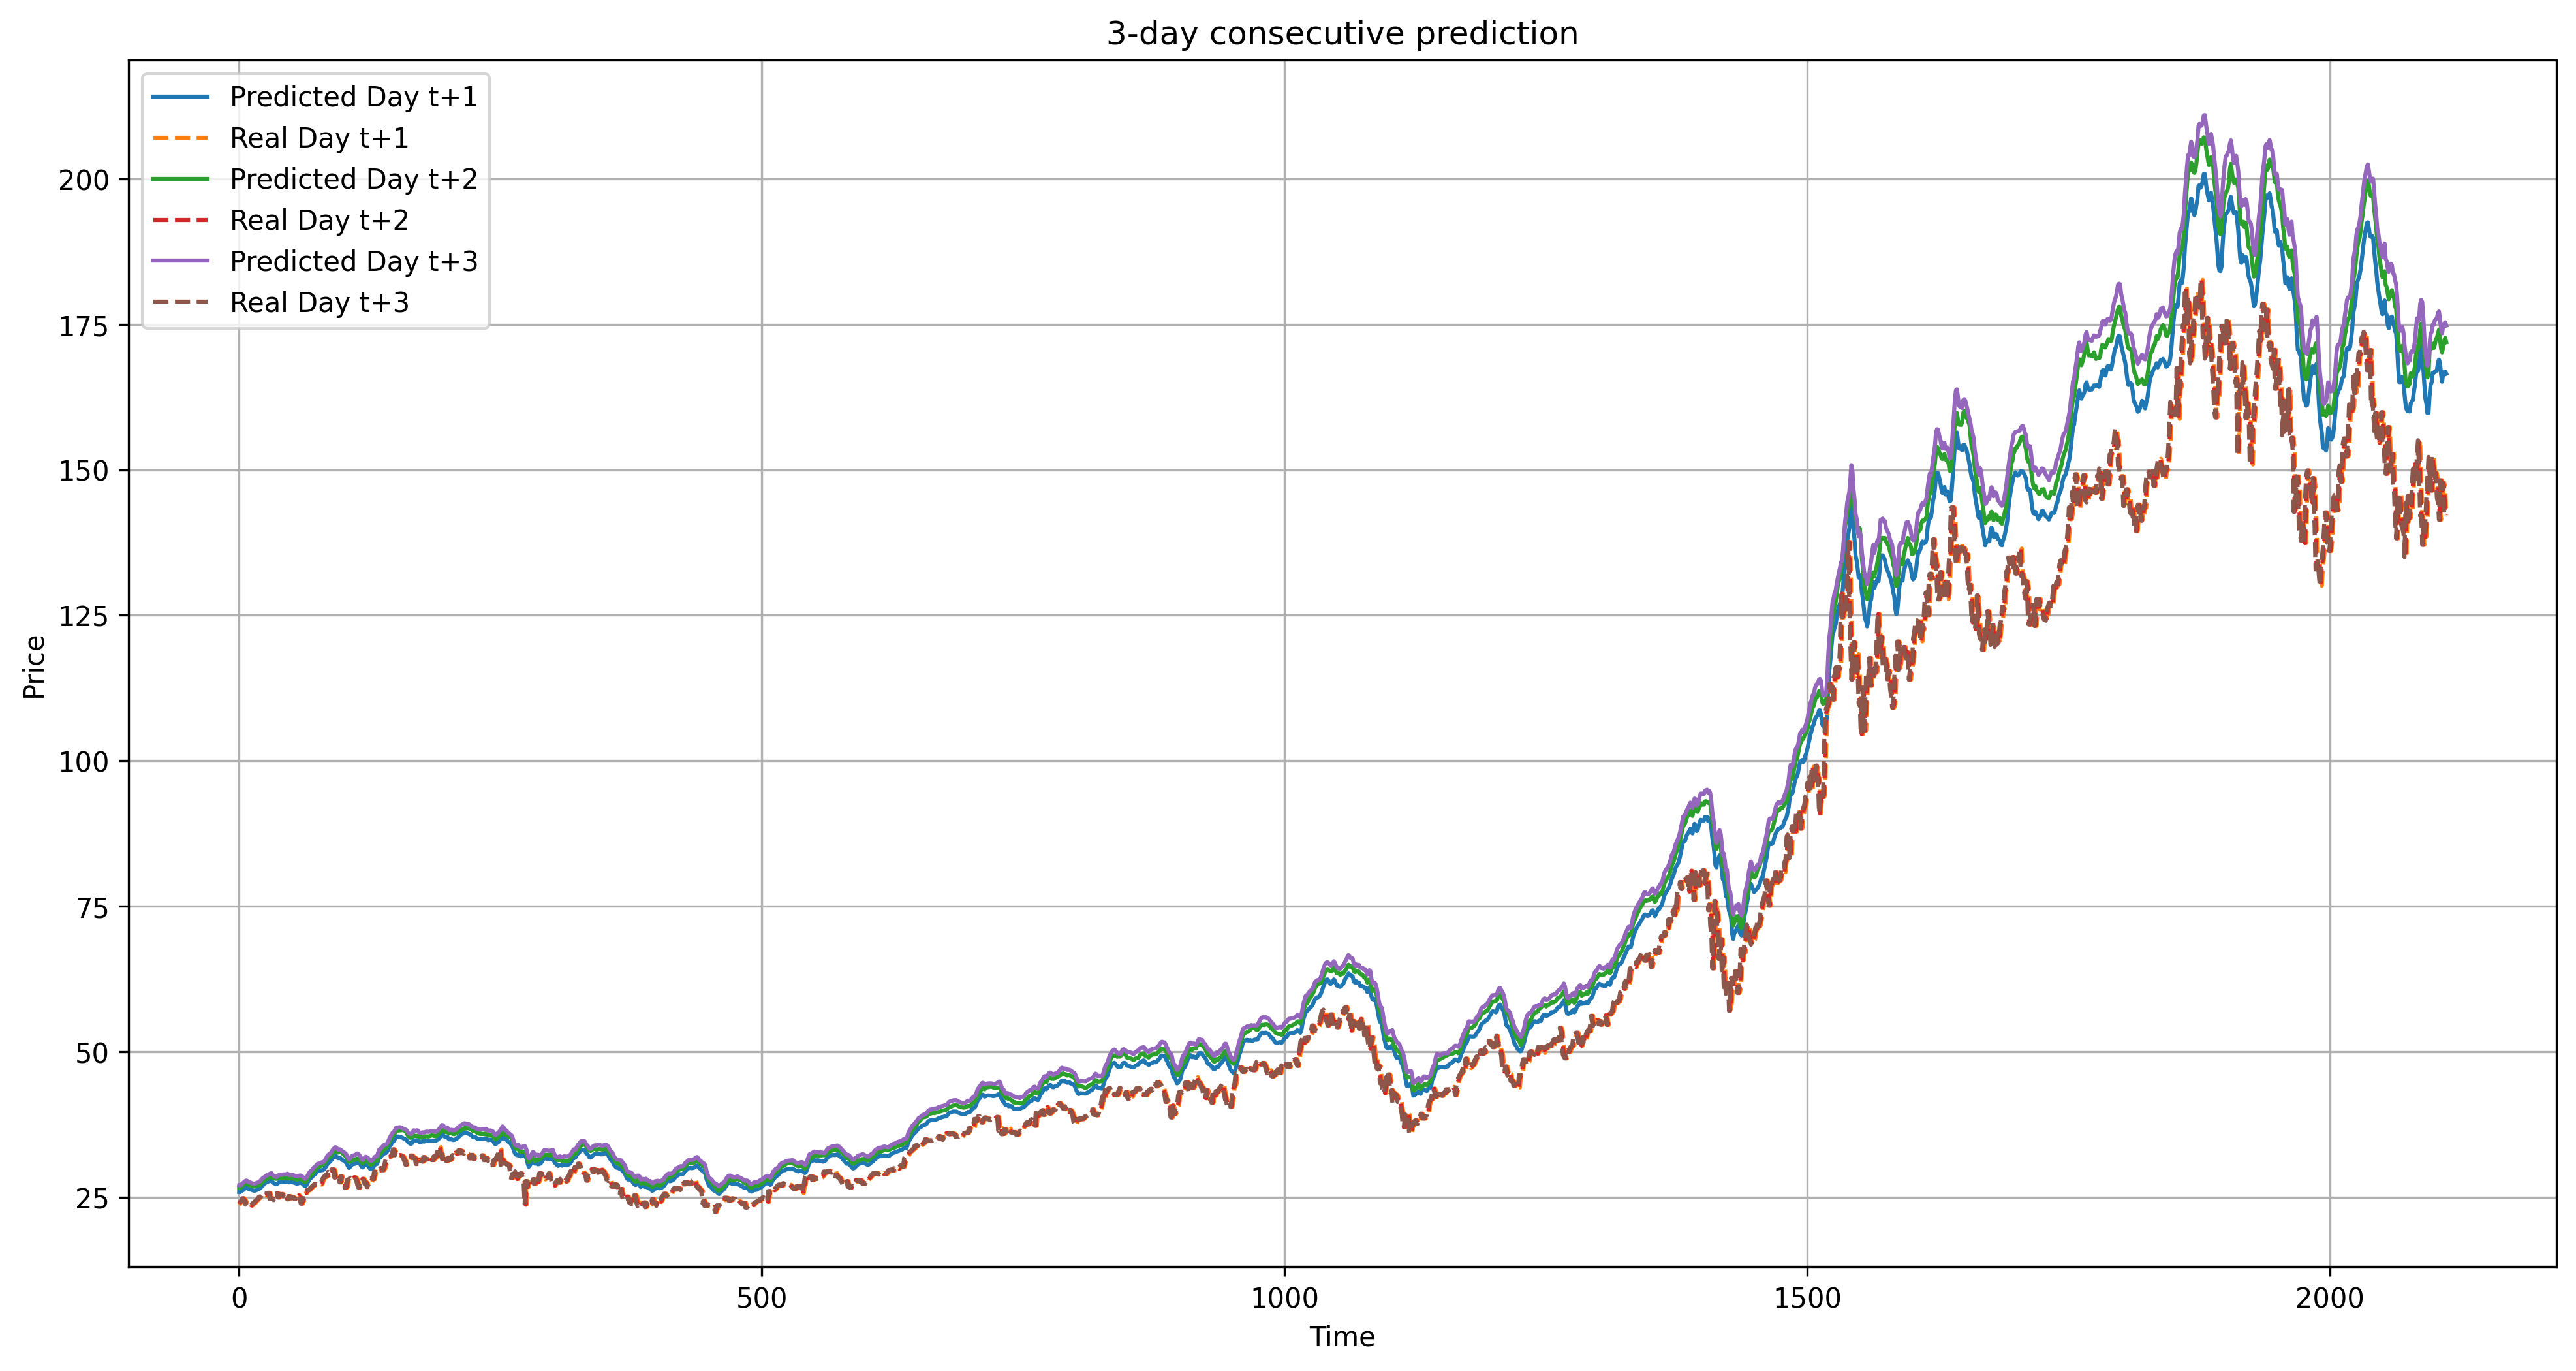

In [15]:
# 11. Visualization
plt.figure(figsize=(16, 8), dpi=300)

for i in range(k):
    plt.plot(y_pred[:, i], label=f'Predicted Day t+{i+1}')
    plt.plot(y_test_real[:, i], linestyle='dashed', label=f'Real Day t+{i+1}')

plt.title(f'{k}-day consecutive prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()